In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite



# Classificação do Dataset Iris utilizando Support Vector Machine (SVM)

**Objetivo:** Este notebook realiza a Análise Exploratória de Dados (EDA), o pré-processamento e a criação de um modelo preditivo baseado exclusivamente no algoritmo **Support Vector Machine (SVM)** para a classificação de espécies de flores Iris.

# 1. IMPORTAÇÃO DAS BIBLIOTECAS


In [2]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas do scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 2. CARREGAMENTO DOS DADOS

O notebook foi criado pela página do dataset Iris Species no Kaggle. Por isso os arquivos já vêm
anexados na pasta `/kaggle/input`, como mostra a primeira célula deste notebook.

O dataset tem dois arquivos: o `Iris.csv` e o `database.sqlite`. Usei o `Iris.csv` porque é um
arquivo de texto simples e pode ser lido diretamente pelo pandas.

Não utilizei a função `load_iris()` do scikit-learn. Todos os dados deste notebook vêm do arquivo
que o Kaggle anexou.

In [3]:
# Caminho do arquivo anexado pelo Kaggle
caminho = "/kaggle/input/datasets/menegidio/iris-species/Iris.csv"

df = pd.read_csv(caminho)


df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# 3. ANÁLISE EXPLORATÓRIA DOS DADOS

Nesta etapa eu observo como os dados estão organizados antes de treinar o modelo. Verifico os tipos
das colunas, se existem valores faltando, como os valores se distribuem e quantas amostras existem
de cada espécie.

In [4]:
# Tipos das colunas e quantidade de registros
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
# Verificação de valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nRegistros duplicados:", df.duplicated().sum())

Valores nulos por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Registros duplicados: 0


In [6]:
# Estatísticas descritivas das colunas numéricas
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


O dataset tem 150 registros e nenhum valor nulo, então não é necessário nenhum tratamento de dados
faltantes.

Nas estatísticas acima é possível ver que as colunas têm faixas de valores diferentes. As medidas de
sépala trabalham com números maiores que as de pétala. Isso será tratado mais adiante com a
padronização.

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


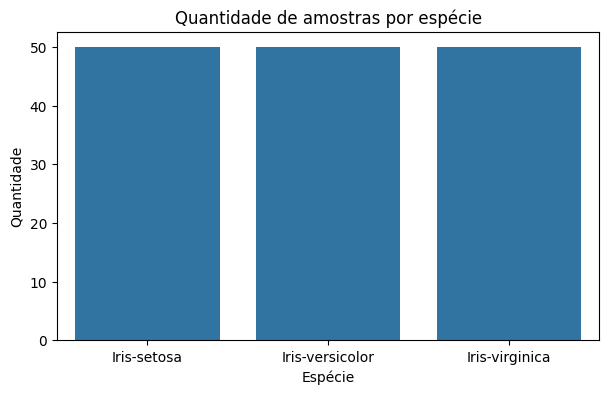

In [7]:
# Quantidade de amostras de cada espécie
print(df["Species"].value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Species")
plt.title("Quantidade de amostras por espécie")
plt.xlabel("Espécie")
plt.ylabel("Quantidade")
plt.show()

O dataset tem 50 amostras de cada espécie, ou seja, está equilibrado.

Isso é importante para a avaliação do modelo. Como as três classes têm o mesmo peso, a acurácia é uma
métrica confiável neste caso. Se uma espécie tivesse muito mais amostras que as outras, a acurácia
poderia enganar.

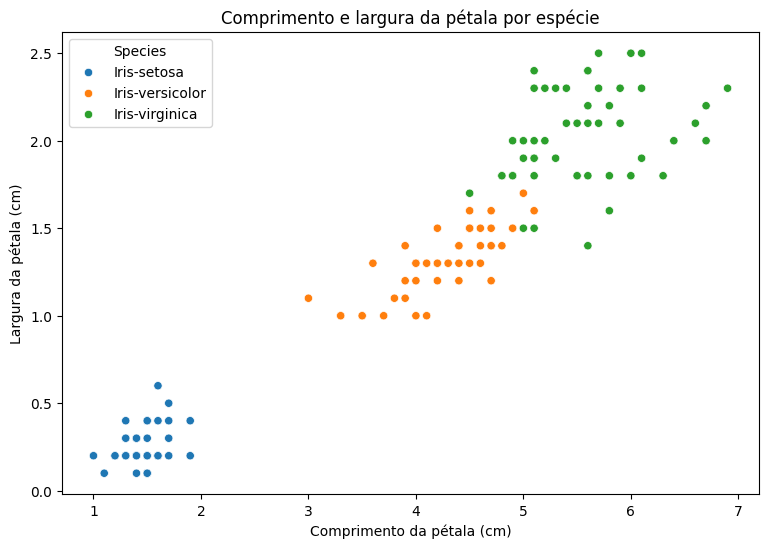

In [8]:
# Gráfico de dispersão usando as medidas de pétala
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species")
plt.title("Comprimento e largura da pétala por espécie")
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.show()

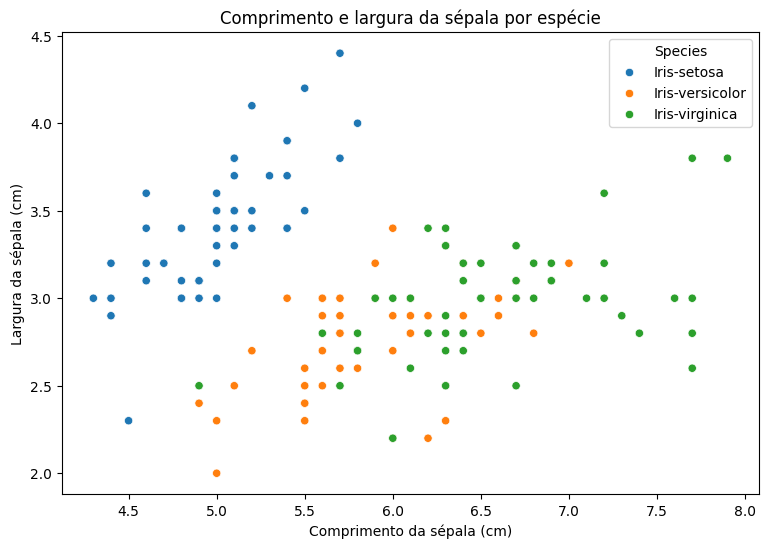

In [9]:
# Gráfico de dispersão usando as medidas de sépala
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="SepalLengthCm", y="SepalWidthCm", hue="Species")
plt.title("Comprimento e largura da sépala por espécie")
plt.xlabel("Comprimento da sépala (cm)")
plt.ylabel("Largura da sépala (cm)")
plt.show()

Comparando os dois gráficos, as medidas de pétala separam melhor as espécies.

No gráfico da pétala os três grupos aparecem bem definidos. A Iris-setosa fica isolada no canto
inferior esquerdo e não se mistura com nenhuma outra. A Iris-versicolor e a Iris-virginica ficam
próximas, mas ainda dá para ver a divisão entre elas.

No gráfico da sépala os pontos ficam muito misturados, principalmente entre versicolor e virginica.

Com isso, espero que o modelo acerte todas as amostras de setosa e que os erros, se houver, aconteçam
entre versicolor e virginica.

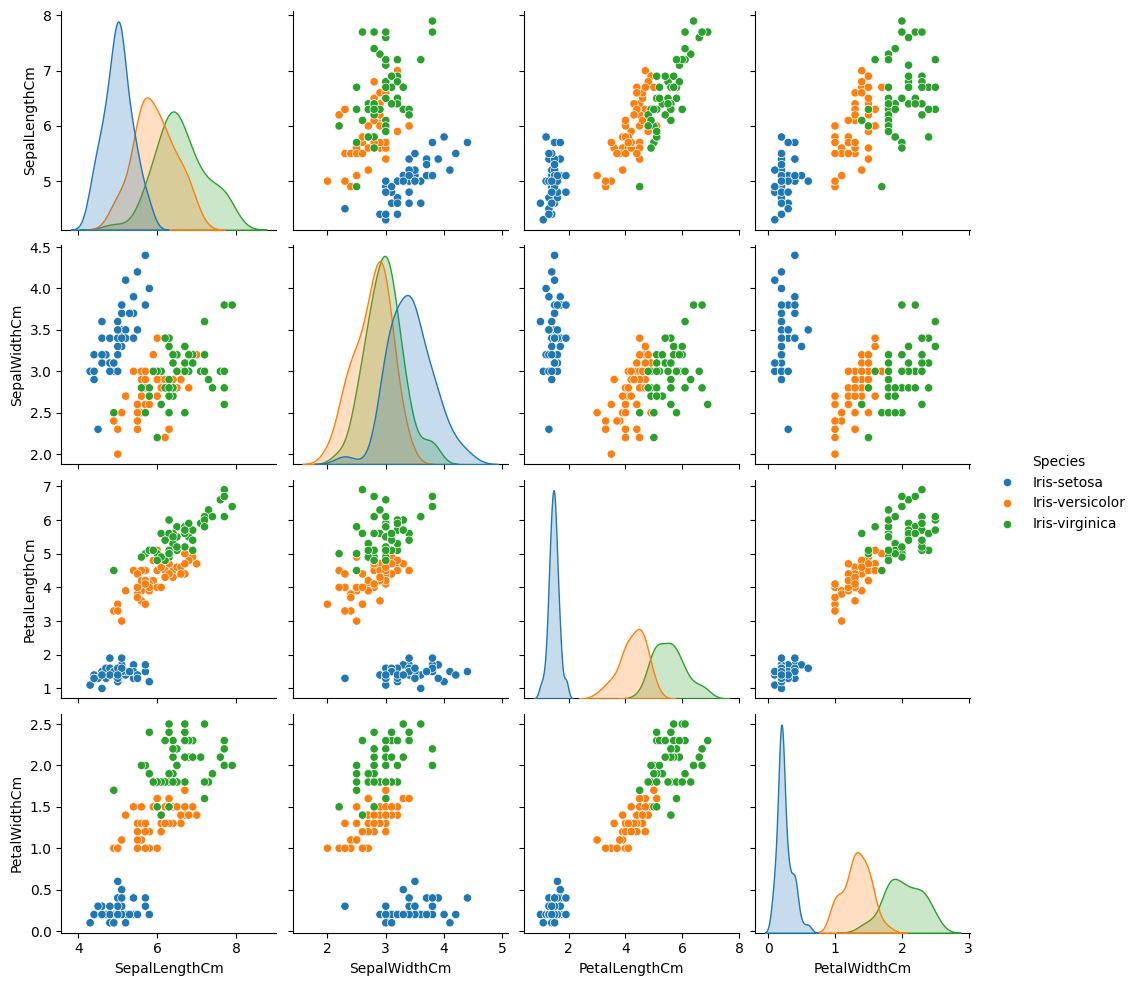

In [10]:
# Visão geral de todos os pares de colunas
sns.pairplot(df.drop(columns=["Id"]), hue="Species")
plt.show()

# 4. PREPARAÇÃO DOS DADOS

Antes de treinar o modelo preciso preparar os dados em três passos:

1. Remover a coluna `Id`
2. Separar as colunas de medidas (X) da coluna de espécie (y)
3. Dividir os dados em treino e teste
4. Padronizar os valores

In [11]:
# A coluna Id é só um número sequencial de 1 a 150 e não ajuda a identificar a espécie.
# Como o arquivo está ordenado por espécie, deixar essa coluna faria o modelo usar o
# número da linha para acertar, o que não é um aprendizado real.
df = df.drop(columns=["Id"])

# X recebe as medidas e y recebe a espécie
X = df.drop(columns=["Species"])
y = df["Species"]

print("Colunas de X:", list(X.columns))
print("Valores de y:", y.unique())

Colunas de X: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Valores de y: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## Divisão entre treino e teste

Separo 80% dos dados para treino e 20% para teste. O modelo aprende apenas com os dados de treino, e
os dados de teste são usados só no final, para verificar se o modelo funciona com dados que ele nunca
viu.

Uso `stratify=y` para que as três espécies fiquem na mesma proporção nos dois conjuntos. Sem isso, o
sorteio poderia deixar muitas amostras de uma espécie só no treino ou só no teste.

O `random_state=42` faz o sorteio ser sempre o mesmo, então quem rodar este notebook novamente vai
obter o mesmo resultado.

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Amostras de treino:", X_treino.shape[0])
print("Amostras de teste:", X_teste.shape[0])

Amostras de treino: 120
Amostras de teste: 30


## Padronização

O SVM usa a distância entre os pontos para encontrar a separação entre as classes. Se uma coluna tem
valores muito maiores que as outras, ela acaba pesando mais no cálculo e atrapalha o resultado.

O `StandardScaler` resolve isso deixando todas as colunas com média 0 e desvio padrão 1.

Aplico o `fit_transform` apenas no treino e o `transform` no teste. Se eu ajustasse o escalonador no
conjunto completo, informações do teste entrariam no treino e a avaliação final ficaria melhor do que
realmente é.

In [13]:
escalonador = StandardScaler()

X_treino = escalonador.fit_transform(X_treino)
X_teste = escalonador.transform(X_teste)

print("Média das colunas no treino:", X_treino.mean(axis=0).round(2))
print("Desvio padrão das colunas no treino:", X_treino.std(axis=0).round(2))

Média das colunas no treino: [-0.  0. -0.  0.]
Desvio padrão das colunas no treino: [1. 1. 1. 1.]


# 5. CRIAÇÃO DO MODELO

O SVM procura a melhor linha de separação entre as classes. Ele escolhe a linha que fica o mais longe
possível dos pontos de cada grupo, criando uma margem de segurança entre eles. Os pontos que ficam na
borda dessa margem são chamados de vetores de suporte e são eles que definem a separação.

Usei o kernel `rbf`, que permite uma separação em formato curvo. Como versicolor e virginica ficam
próximas, uma separação apenas reta pode não ser suficiente.

Os parâmetros `C=1.0` e `gamma="scale"` são os valores padrão do scikit-learn. O `C` controla o
quanto o modelo aceita errar no treino para conseguir uma margem maior, e o `gamma` controla o
alcance de cada ponto no cálculo da separação.

In [14]:
# Criação do modelo
modelo = SVC(kernel="rbf", C=1.0, gamma="scale")

# Treinamento com os dados de treino
modelo.fit(X_treino, y_treino)

print("Modelo treinado.")
print("Vetores de suporte por classe:", modelo.n_support_)

Modelo treinado.
Vetores de suporte por classe: [10 18 19]


In [15]:
# Previsões sobre os dados de teste
y_pred = modelo.predict(X_teste)

print("Previsto:", y_pred)
print("Real:    ", y_teste.values)

Previsto: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
Real:     ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica

# 6. AVALIAÇÃO DO MODELO

Avalio o modelo usando as 30 amostras de teste, que não foram usadas no treinamento.

As métricas utilizadas são:

- Acurácia: quantas previsões o modelo acertou no total
- Precisão: das amostras que o modelo disse ser de uma espécie, quantas eram mesmo
- Revocação: das amostras que eram de uma espécie, quantas o modelo encontrou
- F1-score: junta precisão e revocação em um único número
- Matriz de confusão: mostra onde o modelo errou e qual espécie ele confundiu com qual

In [16]:
# Acurácia geral
acuracia = accuracy_score(y_teste, y_pred)
print(f"Acurácia: {acuracia * 100:.2f}%")

Acurácia: 96.67%


In [17]:
# Precisão, revocação e F1-score para cada espécie
print(classification_report(y_teste, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



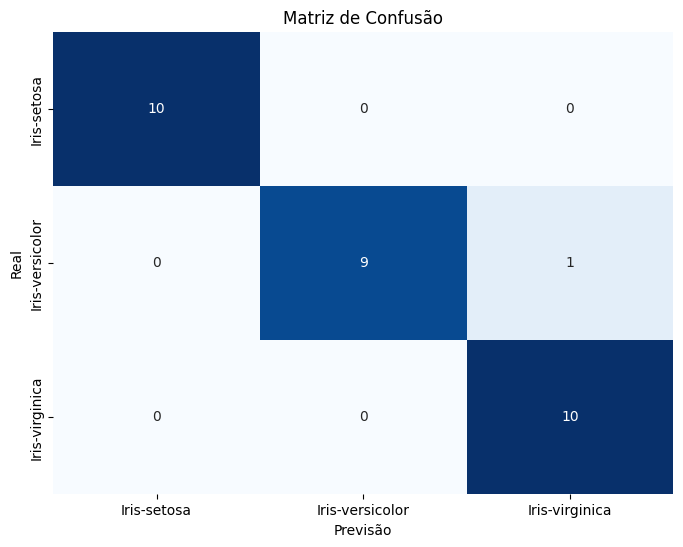

In [18]:
# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

Na matriz de confusão, os números da diagonal são os acertos. Qualquer número fora da diagonal é um
erro, e a posição dele mostra qual espécie foi confundida com qual.

O resultado confirma o que eu tinha observado nos gráficos de dispersão: a setosa foi classificada
corretamente em todos os casos, porque ela fica separada das outras duas. Os erros, quando aparecem,
acontecem entre versicolor e virginica, que são as espécies com medidas mais parecidas.

# 7. CONCLUSÃO

Neste notebook usei o dataset Iris obtido do Kaggle para criar um modelo de classificação com SVM.

Na análise exploratória verifiquei que o dataset não tem valores nulos e está equilibrado, com 50
amostras de cada espécie. Também observei que as medidas de pétala separam melhor as espécies do que
as medidas de sépala.

Na preparação removi a coluna `Id`, separei os dados em treino e teste com 80% e 20%, e padronizei os
valores com o `StandardScaler`.

O modelo SVM com kernel `rbf` teve um bom desempenho no conjunto de teste. As métricas de acurácia,
precisão, revocação e F1-score ficaram próximas entre si, o que era esperado por causa do equilíbrio
entre as classes.

Alguns pontos que limitam este resultado:

- O dataset tem apenas 150 registros, então o conjunto de teste tem só 30 amostras. Cada erro muda a
  acurácia em mais de 3 pontos percentuais, o que torna o resultado sensível ao sorteio dos dados.
- O Iris é um dataset conhecido por ser fácil de separar. Um resultado alto aqui não significa que o
  mesmo processo teria o mesmo desempenho em dados reais, com mais ruído e classes desequilibradas.
- Usei os valores padrão de `C` e `gamma`. Testar outros valores poderia melhorar o resultado.

Como continuação deste trabalho, seria possível testar diferentes valores de `C` e `gamma`, comparar
outros kernels e avaliar o modelo com validação cruzada em vez de uma única divisão entre treino e
teste.